# Traceback Analysis of HMM Profile

This notebook is designed to do the following:
- Scrap the titles of the profiles to collect the traces used
- Create an object compatible with the vrHMM "metadata" function that filters traces to just those specified in the dictionary
- Run the vrHMM, evaluating the amino_acid class against only itself and using only those traces that curated the profile to do so
- Create a traceback matrix which shows how each of the traces aligned to the profile in a convenient format

## Config

In [1]:
# Your existing paths...
circle_test_dir = "/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/optimization/Test_HMM_on_Optimized_Scales/amino_acid_tests"


## Data Parsing

In [2]:
"""
HMM Traceback Grid Visualization

Creates a 5x4 grid of traceback overlays for all 20 amino acids.
"""

import json
import re
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt


# Standard amino acid order
AMINO_ACIDS = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
               'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


def parse_state_entry(state_entry: str) -> Tuple[str, int]:
    """Parse a state entry like 'Match_5' into (state_type, state_index)."""
    parts = state_entry.split('_')
    state_type = parts[0]
    state_index = int(parts[1])
    return state_type, state_index


def compute_traceback_trajectory(full_path: List[str]) -> List[Dict]:
    """Convert a full path into a trajectory with position information."""
    trajectory = []
    segment_idx = 0
    
    for i, entry in enumerate(full_path):
        state_type, state_idx = parse_state_entry(entry)
        is_emitting = (state_type == 'Match')
        
        trajectory.append({
            'step': i,
            'segment_idx': segment_idx,
            'state_idx': state_idx,
            'state_type': state_type,
            'is_emitting': is_emitting,
            'entry': entry
        })
        
        if is_emitting:
            segment_idx += 1
    
    return trajectory


def find_results_file_in_subdir(subdir: Path) -> Optional[Path]:
    """Find the results JSON file in a subdir (handles timestamped filenames)."""
    results_files = list(subdir.glob("results_*.json"))
    if not results_files:
        return None
    # Return most recent if multiple
    results_files.sort(key=lambda x: x.stat().st_mtime, reverse=True)
    return results_files[0]


def extract_aa_from_subdir(subdir_name: str) -> Optional[str]:
    """Extract amino acid letter from subdir name like 'A_circle_test'."""
    match = re.match(r'^([A-Z])_', subdir_name)
    if match:
        return match.group(1)
    return None


def load_all_results_from_parent_dir(parent_dir: str) -> Dict[str, Dict]:
    """
    Load results from all amino acid subdirs in a parent directory.
    
    Returns:
        Dict mapping amino acid -> {trace_key: result_dict}
    """
    parent = Path(parent_dir)
    all_results = {}
    
    for subdir in sorted(parent.iterdir()):
        if not subdir.is_dir():
            continue
        
        aa = extract_aa_from_subdir(subdir.name)
        if aa is None:
            print(f"  Skipping {subdir.name} - couldn't extract AA")
            continue
        
        results_file = find_results_file_in_subdir(subdir)
        if results_file is None:
            print(f"  No results file found in {subdir.name}")
            continue
        
        with open(results_file, 'r') as f:
            data = json.load(f)
        
        all_results[aa] = data
        print(f"  Loaded {aa}: {len(data)} traces from {results_file.name}")
    
    return all_results


def draw_diagonal_guides(
    ax: plt.Axes,
    num_states: int,
    max_segment: int,
    offset: int = 5,
    line_color: str = 'red',
    line_style: str = '--',
    line_width: float = 1.0,
    line_alpha: float = 0.5
) -> None:
    """
    Draw two dashed diagonal guide lines at +/- offset from y=x.
    
    Since y is inverted (state 0 at top), the "ideal" diagonal goes from
    top-left (segment 0, state 0) to bottom-right (segment N, state N).
    
    Args:
        ax: Matplotlib axes to draw on
        num_states: Number of HMM states
        max_segment: Maximum segment index
        offset: Distance from y=x line (draws at +offset and -offset)
        line_color: Color of guide lines
        line_style: Line style ('--' for dashed, ':' for dotted, etc.)
        line_width: Width of guide lines
        line_alpha: Transparency of guide lines
    """
    for off in [offset, -offset]:
        # For inverted y-axis: y_inverted = num_states - 1 - state_idx
        # Ideal path: state_idx = segment_idx, so y_inverted = num_states - 1 - segment_idx
        # With offset: state_idx = segment_idx + off
        # So: y_inverted = num_states - 1 - (segment_idx + off)
        
        x_vals = np.array([0, max_segment + 1])
        y_vals = (num_states - 1) - (x_vals + off)
        
        ax.plot(x_vals, y_vals, linestyle=line_style, color=line_color,
                linewidth=line_width, alpha=line_alpha, zorder=1)


def plot_single_aa_traceback(
    ax: plt.Axes,
    results: Dict[str, Dict],
    aa: str,
    num_states: int = 25,
    line_alpha: float = 0.6,
    line_width: float = 1.5,
    colormap: str = 'tab10',
    guide_offset: int = None,
    guide_color: str = 'red',
    guide_alpha: float = 0.4
) -> int:
    """
    Plot traceback overlay for a single amino acid on given axes.
    
    Args:
        ax: Matplotlib axes
        results: Dict of trace results
        aa: Amino acid letter
        num_states: Number of HMM states
        line_alpha: Transparency of trace lines
        line_width: Width of trace lines
        colormap: Colormap for traces
        guide_offset: If provided, draw diagonal guide lines at this increment
        guide_color: Color for guide lines
        guide_alpha: Transparency for guide lines
    
    Returns:
        Number of valid traces plotted
    """
    valid_traces = {k: v for k, v in results.items() 
                   if v.get('full_path') and len(v['full_path']) > 0}
    
    if not valid_traces:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(aa, fontsize=14, fontweight='bold')
        return 0
    
    # Find max segment for this AA
    max_segment = 0
    for result in valid_traces.values():
        traj = compute_traceback_trajectory(result['full_path'])
        if traj:
            max_seg = max(t['segment_idx'] for t in traj)
            max_segment = max(max_segment, max_seg)
    
    # Draw diagonal guide lines FIRST (behind traces)
    if guide_offset is not None and guide_offset > 0:
        draw_diagonal_guides(
            ax, num_states, max_segment,
            offset=guide_offset,
            line_color=guide_color,
            line_alpha=guide_alpha
        )
    
    # Generate colors
    n_traces = len(valid_traces)
    cmap = plt.cm.get_cmap(colormap)
    colors = [cmap(i / max(n_traces - 1, 1)) for i in range(n_traces)]
    
    for idx, (trace_key, result) in enumerate(valid_traces.items()):
        full_path = result['full_path']
        trajectory = compute_traceback_trajectory(full_path)
        
        if not trajectory:
            continue
        
        x = [t['segment_idx'] for t in trajectory]
        y = [t['state_idx'] for t in trajectory]
        
        # Invert y so state 0 is at top
        y_inverted = [num_states - 1 - yi for yi in y]
        
        ax.plot(x, y_inverted, '-', color=colors[idx], linewidth=line_width,
                alpha=line_alpha, solid_capstyle='round', zorder=2)
    
    # Formatting
    ax.set_title(f'{aa} (n={n_traces})', fontsize=12, fontweight='bold')
    ax.set_ylim(-0.5, num_states - 0.5)
    ax.set_xlim(-0.5, max_segment + 0.5)
    
    # Only show some y-tick labels to reduce clutter
    ax.set_yticks([0, num_states//2, num_states-1])
    ax.set_yticklabels([num_states-1, num_states//2, 0])
    
    return n_traces


def plot_traceback_grid(
    parent_dir: str,
    num_states: int = 25,
    figsize: Tuple[int, int] = (20, 16),
    save_path: str = None,
    line_alpha: float = 0.6,
    line_width: float = 1.5,
    colormap: str = 'tab10',
    suptitle: str = "HMM Traceback Overlays - All Amino Acids",
    guide_offset: int = None,
    guide_color: str = 'red',
    guide_alpha: float = 0.4
) -> plt.Figure:
    """
    Create a 5x4 grid of traceback overlays for all 20 amino acids.
    
    Args:
        parent_dir: Directory containing subdirs like 'A_circle_test', etc.
        num_states: Number of HMM states
        figsize: Figure size (width, height)
        save_path: If provided, save figure to this path
        line_alpha: Transparency of trace lines
        line_width: Width of trace lines
        colormap: Matplotlib colormap for trace colors
        suptitle: Super title for the entire figure
        guide_offset: If provided, draw diagonal guide lines at this increment
        guide_color: Color for diagonal guide lines
        guide_alpha: Transparency for diagonal guide lines
        
    Returns:
        matplotlib Figure object
    """
    print(f"Loading results from: {parent_dir}")
    all_results = load_all_results_from_parent_dir(parent_dir)
    
    if not all_results:
        print("No results found!")
        return None
    
    print(f"\nFound results for {len(all_results)} amino acids")
    
    # Create 5x4 grid
    fig, axes = plt.subplots(5, 4, figsize=figsize)
    axes = axes.flatten()
    
    total_traces = 0
    
    for idx, aa in enumerate(AMINO_ACIDS):
        ax = axes[idx]
        
        if aa in all_results:
            n_traces = plot_single_aa_traceback(
                ax, all_results[aa], aa,
                num_states=num_states,
                line_alpha=line_alpha,
                line_width=line_width,
                colormap=colormap,
                guide_offset=guide_offset,
                guide_color=guide_color,
                guide_alpha=guide_alpha
            )
            total_traces += n_traces
        else:
            ax.text(0.5, 0.5, 'Missing', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='red')
            ax.set_title(aa, fontsize=12, fontweight='bold')
    
    # Add shared axis labels
    fig.text(0.5, 0.02, 'Segment Index', ha='center', fontsize=14)
    fig.text(0.02, 0.5, 'HMM State Index', va='center', rotation='vertical', fontsize=14)
    
    fig.suptitle(f"{suptitle}\n(Total: {total_traces} traces)", fontsize=16, fontweight='bold')
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\nSaved plot to {save_path}")
    
    return fig


def plot_traceback_heatmap_grid(
    parent_dir: str,
    num_states: int = 25,
    figsize: Tuple[int, int] = (20, 16),
    save_path: str = None,
    suptitle: str = "State Visitation Heatmaps - All Amino Acids"
) -> plt.Figure:
    """
    Create a 5x4 grid of state visitation heatmaps for all 20 amino acids.
    """
    print(f"Loading results from: {parent_dir}")
    all_results = load_all_results_from_parent_dir(parent_dir)
    
    if not all_results:
        print("No results found!")
        return None
    
    fig, axes = plt.subplots(5, 4, figsize=figsize)
    axes = axes.flatten()
    
    for idx, aa in enumerate(AMINO_ACIDS):
        ax = axes[idx]
        
        if aa not in all_results:
            ax.text(0.5, 0.5, 'Missing', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='red')
            ax.set_title(aa, fontsize=12, fontweight='bold')
            continue
        
        results = all_results[aa]
        valid_traces = {k: v for k, v in results.items() 
                       if v.get('full_path') and len(v['full_path']) > 0}
        
        if not valid_traces:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_title(aa, fontsize=12, fontweight='bold')
            continue
        
        # Find max segment
        max_segment = 0
        for result in valid_traces.values():
            traj = compute_traceback_trajectory(result['full_path'])
            if traj:
                max_seg = max(t['segment_idx'] for t in traj)
                max_segment = max(max_segment, max_seg)
        max_segment += 1
        
        # Build heatmap (Match states only)
        counts = np.zeros((num_states, max_segment))
        for result in valid_traces.values():
            traj = compute_traceback_trajectory(result.get('full_path', []))
            for t in traj:
                seg = t['segment_idx']
                state = t['state_idx']
                if t['state_type'] == 'Match' and state < num_states and seg < max_segment:
                    counts[state, seg] += 1
        
        # Plot heatmap (invert so state 0 at top)
        im = ax.imshow(counts[::-1], aspect='auto', cmap='Blues', origin='lower')
        ax.set_title(f'{aa} (n={len(valid_traces)})', fontsize=12, fontweight='bold')
        
        # Minimal ticks
        ax.set_yticks([0, num_states//2, num_states-1])
        ax.set_yticklabels([num_states-1, num_states//2, 0])
    
    fig.text(0.5, 0.02, 'Segment Index', ha='center', fontsize=14)
    fig.text(0.02, 0.5, 'HMM State Index', va='center', rotation='vertical', fontsize=14)
    fig.suptitle(suptitle, fontsize=16, fontweight='bold')
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\nSaved plot to {save_path}")
    
    return fig


# # =============================================================================
# # USAGE EXAMPLE
# # =============================================================================
# if __name__ == "__main__":
#     # Example usage
#     parent_dir = "/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/New_Results_after_proper_15_5_5/Final_validation_results/Amino_Acid_Circle_Tests"
    
#     # Generate overlay grid
#     fig = plot_traceback_grid(
#         parent_dir,
#         num_states=25,
#         save_path="./traceback_grid_overlay.pdf"
#     )
#     plt.show()
    
#     # Generate heatmap grid
#     fig = plot_traceback_heatmap_grid(
#         parent_dir,
#         num_states=25,
#         save_path="./traceback_grid_heatmap.pdf"
#     )
#     plt.show()

Loading results from: /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/optimization/Test_HMM_on_Optimized_Scales/amino_acid_tests
  Loaded A: 5 traces from results_20way_barycenter_scale1.0_20260204_113751.json
  Loaded C: 5 traces from results_20way_barycenter_scale1.0_20260204_113809.json
  Loaded D: 5 traces from results_20way_barycenter_scale1.0_20260204_113825.json
  Loaded E: 5 traces from results_20way_barycenter_scale1.0_20260204_113841.json
  Loaded F: 5 traces from results_20way_barycenter_scale1.0_20260204_113857.json
  Loaded G: 5 traces from results_20way_barycenter_scale1.0_20260204_113912.json
  Loaded H: 5 traces from results_20way_barycenter_scale1.0_20260204_113928.json
  Loaded I: 5 traces from results_20way_barycenter_scale1.0_20260204_113942.json
  Loaded K: 5 traces from results_20way_barycenter_scale1.0_20260204_113958.json
  Loaded L: 5 traces from results_20way_barycenter_scale1.0_20260204_114016.json
  Loaded M: 5 traces from results_20way_

/tmp/ipykernel_3077301/3569344296.py:200: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap)
/tmp/ipykernel_3077301/3569344296.py:200: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap)
/tmp/ipykernel_3077301/3569344296.py:200: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap)
/tmp/ipykernel_3077301/3569344296.py:200: MatplotlibDeprecationWarning: The get_cmap function was depre


Saved plot to ./traceback_grid_with_guides.pdf


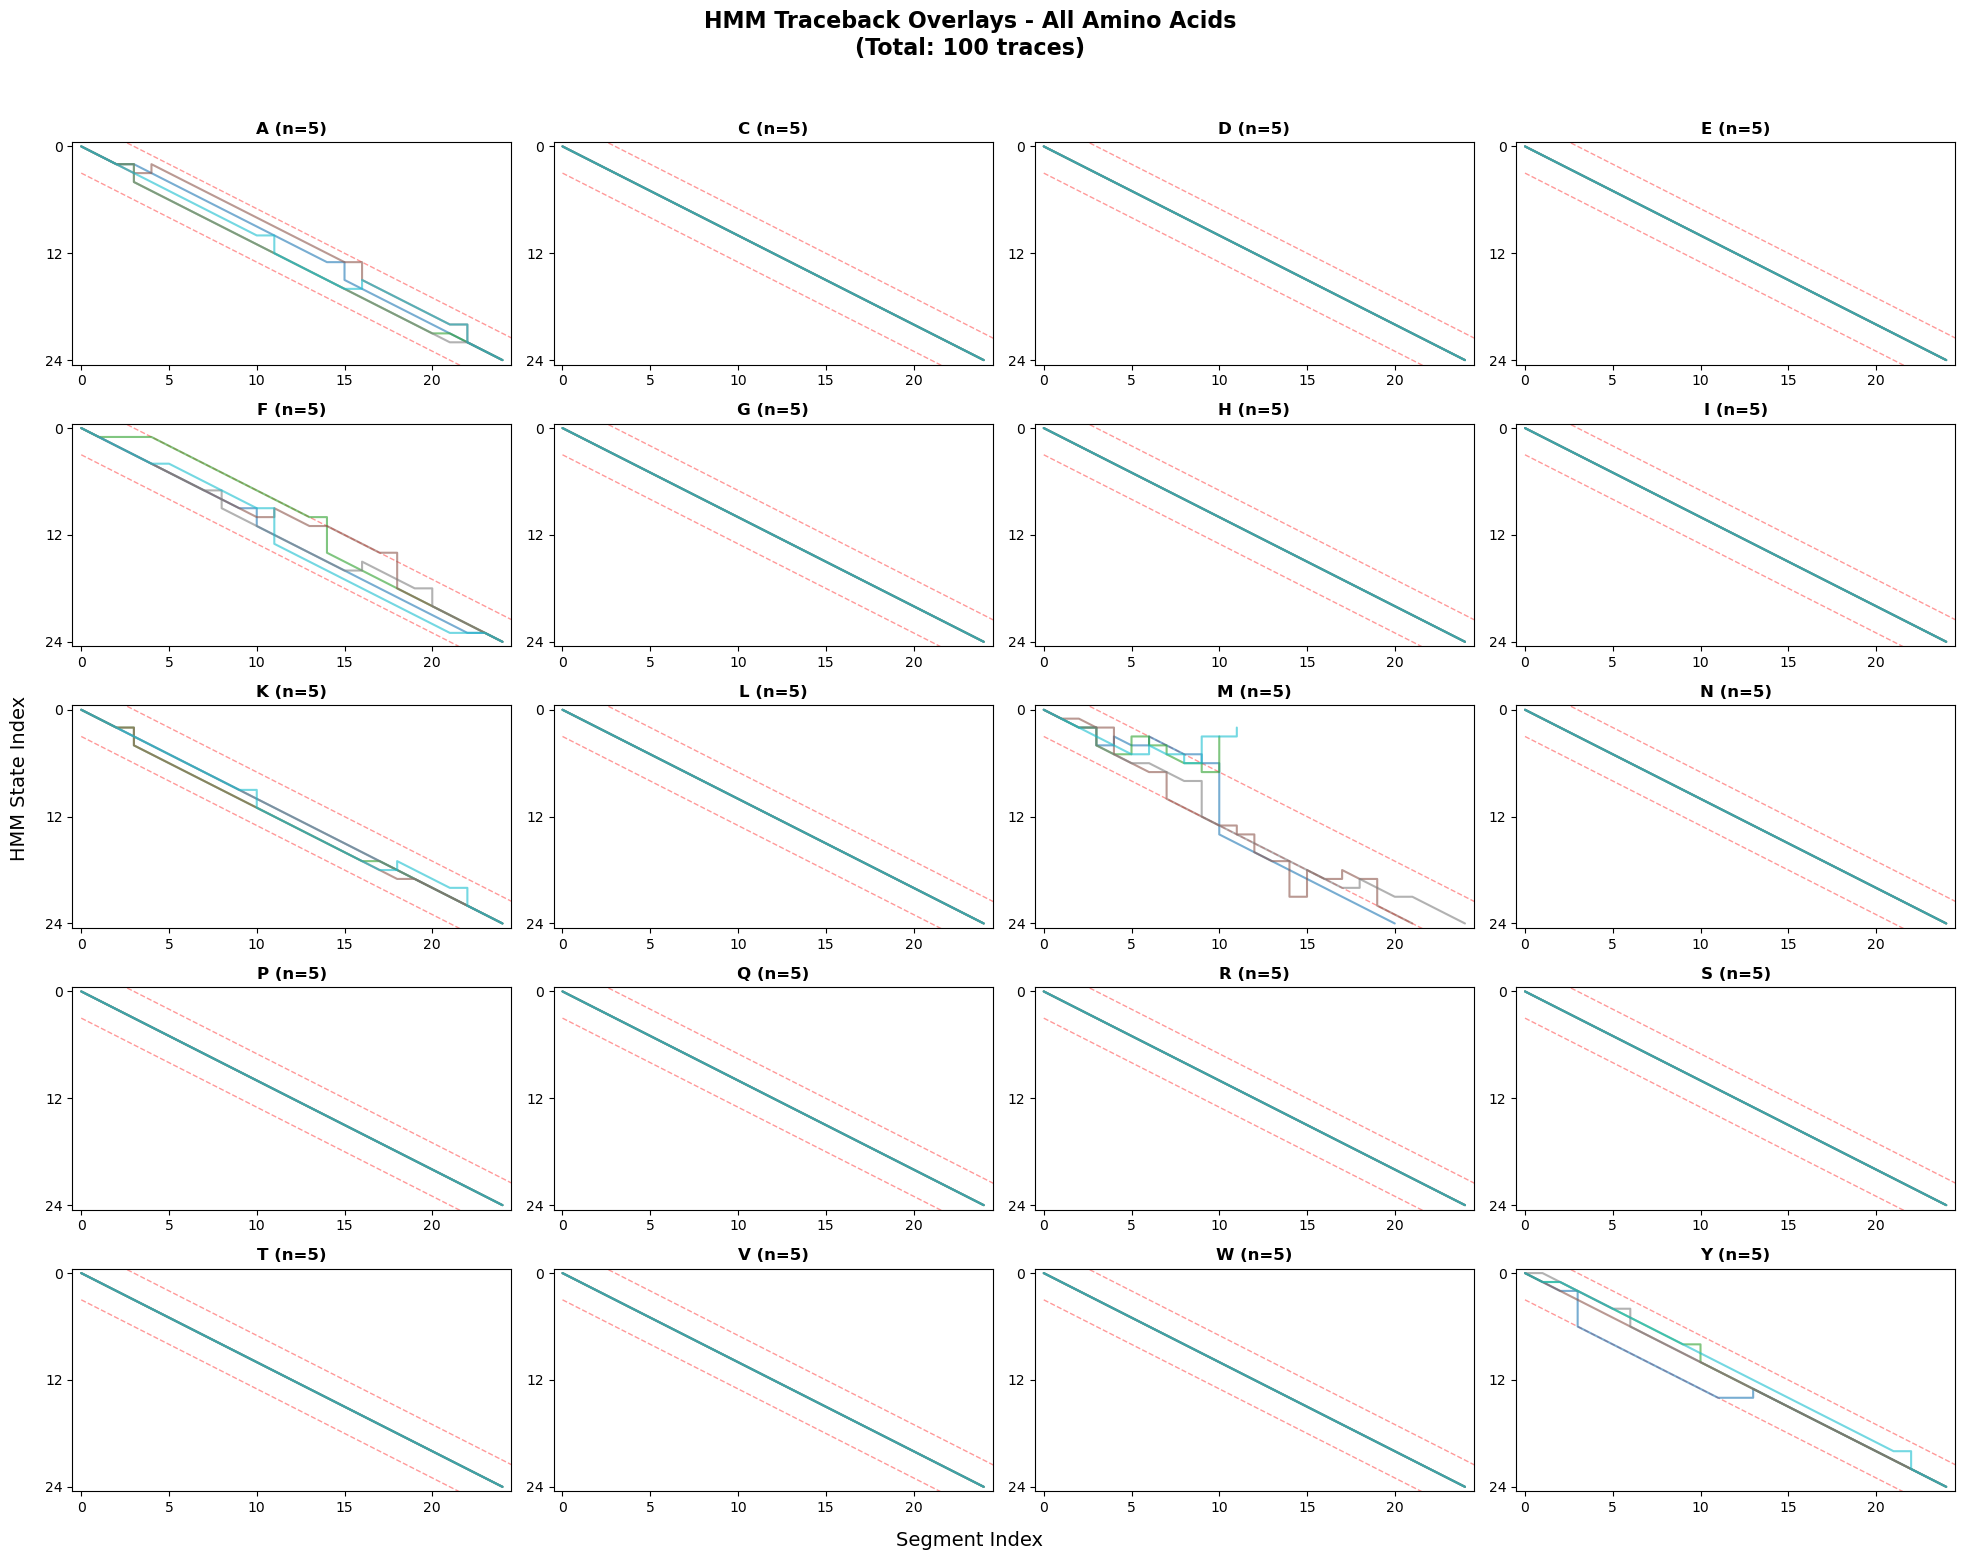

In [3]:
# Draw diagonal guides every 5 states
fig = plot_traceback_grid(
    circle_test_dir,
    num_states=25,
    save_path="./traceback_grid_with_guides.pdf",
    guide_offset=3,        # Diagonal lines at 0, ±5, ±10, ±15, etc.
    guide_color='red',     # Red dashed lines
    guide_alpha=0.4        # Semi-transparent
)
plt.show()

# # Or with different spacing
# fig = plot_traceback_grid(
#     circle_test_dir,
#     num_states=25,
#     guide_offset=3,        # Tighter spacing: 0, ±3, ±6, ±9, etc.
#     guide_color='gray',    # Gray guides instead
#     guide_alpha=0.3
# )

Loading results from: /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/optimization/Test_HMM_on_Optimized_Scales/amino_acid_tests
  Loaded A: 5 traces from results_20way_barycenter_scale1.0_20260204_113751.json
  Loaded C: 5 traces from results_20way_barycenter_scale1.0_20260204_113809.json
  Loaded D: 5 traces from results_20way_barycenter_scale1.0_20260204_113825.json
  Loaded E: 5 traces from results_20way_barycenter_scale1.0_20260204_113841.json
  Loaded F: 5 traces from results_20way_barycenter_scale1.0_20260204_113857.json
  Loaded G: 5 traces from results_20way_barycenter_scale1.0_20260204_113912.json
  Loaded H: 5 traces from results_20way_barycenter_scale1.0_20260204_113928.json
  Loaded I: 5 traces from results_20way_barycenter_scale1.0_20260204_113942.json
  Loaded K: 5 traces from results_20way_barycenter_scale1.0_20260204_113958.json
  Loaded L: 5 traces from results_20way_barycenter_scale1.0_20260204_114016.json
  Loaded M: 5 traces from results_20way_

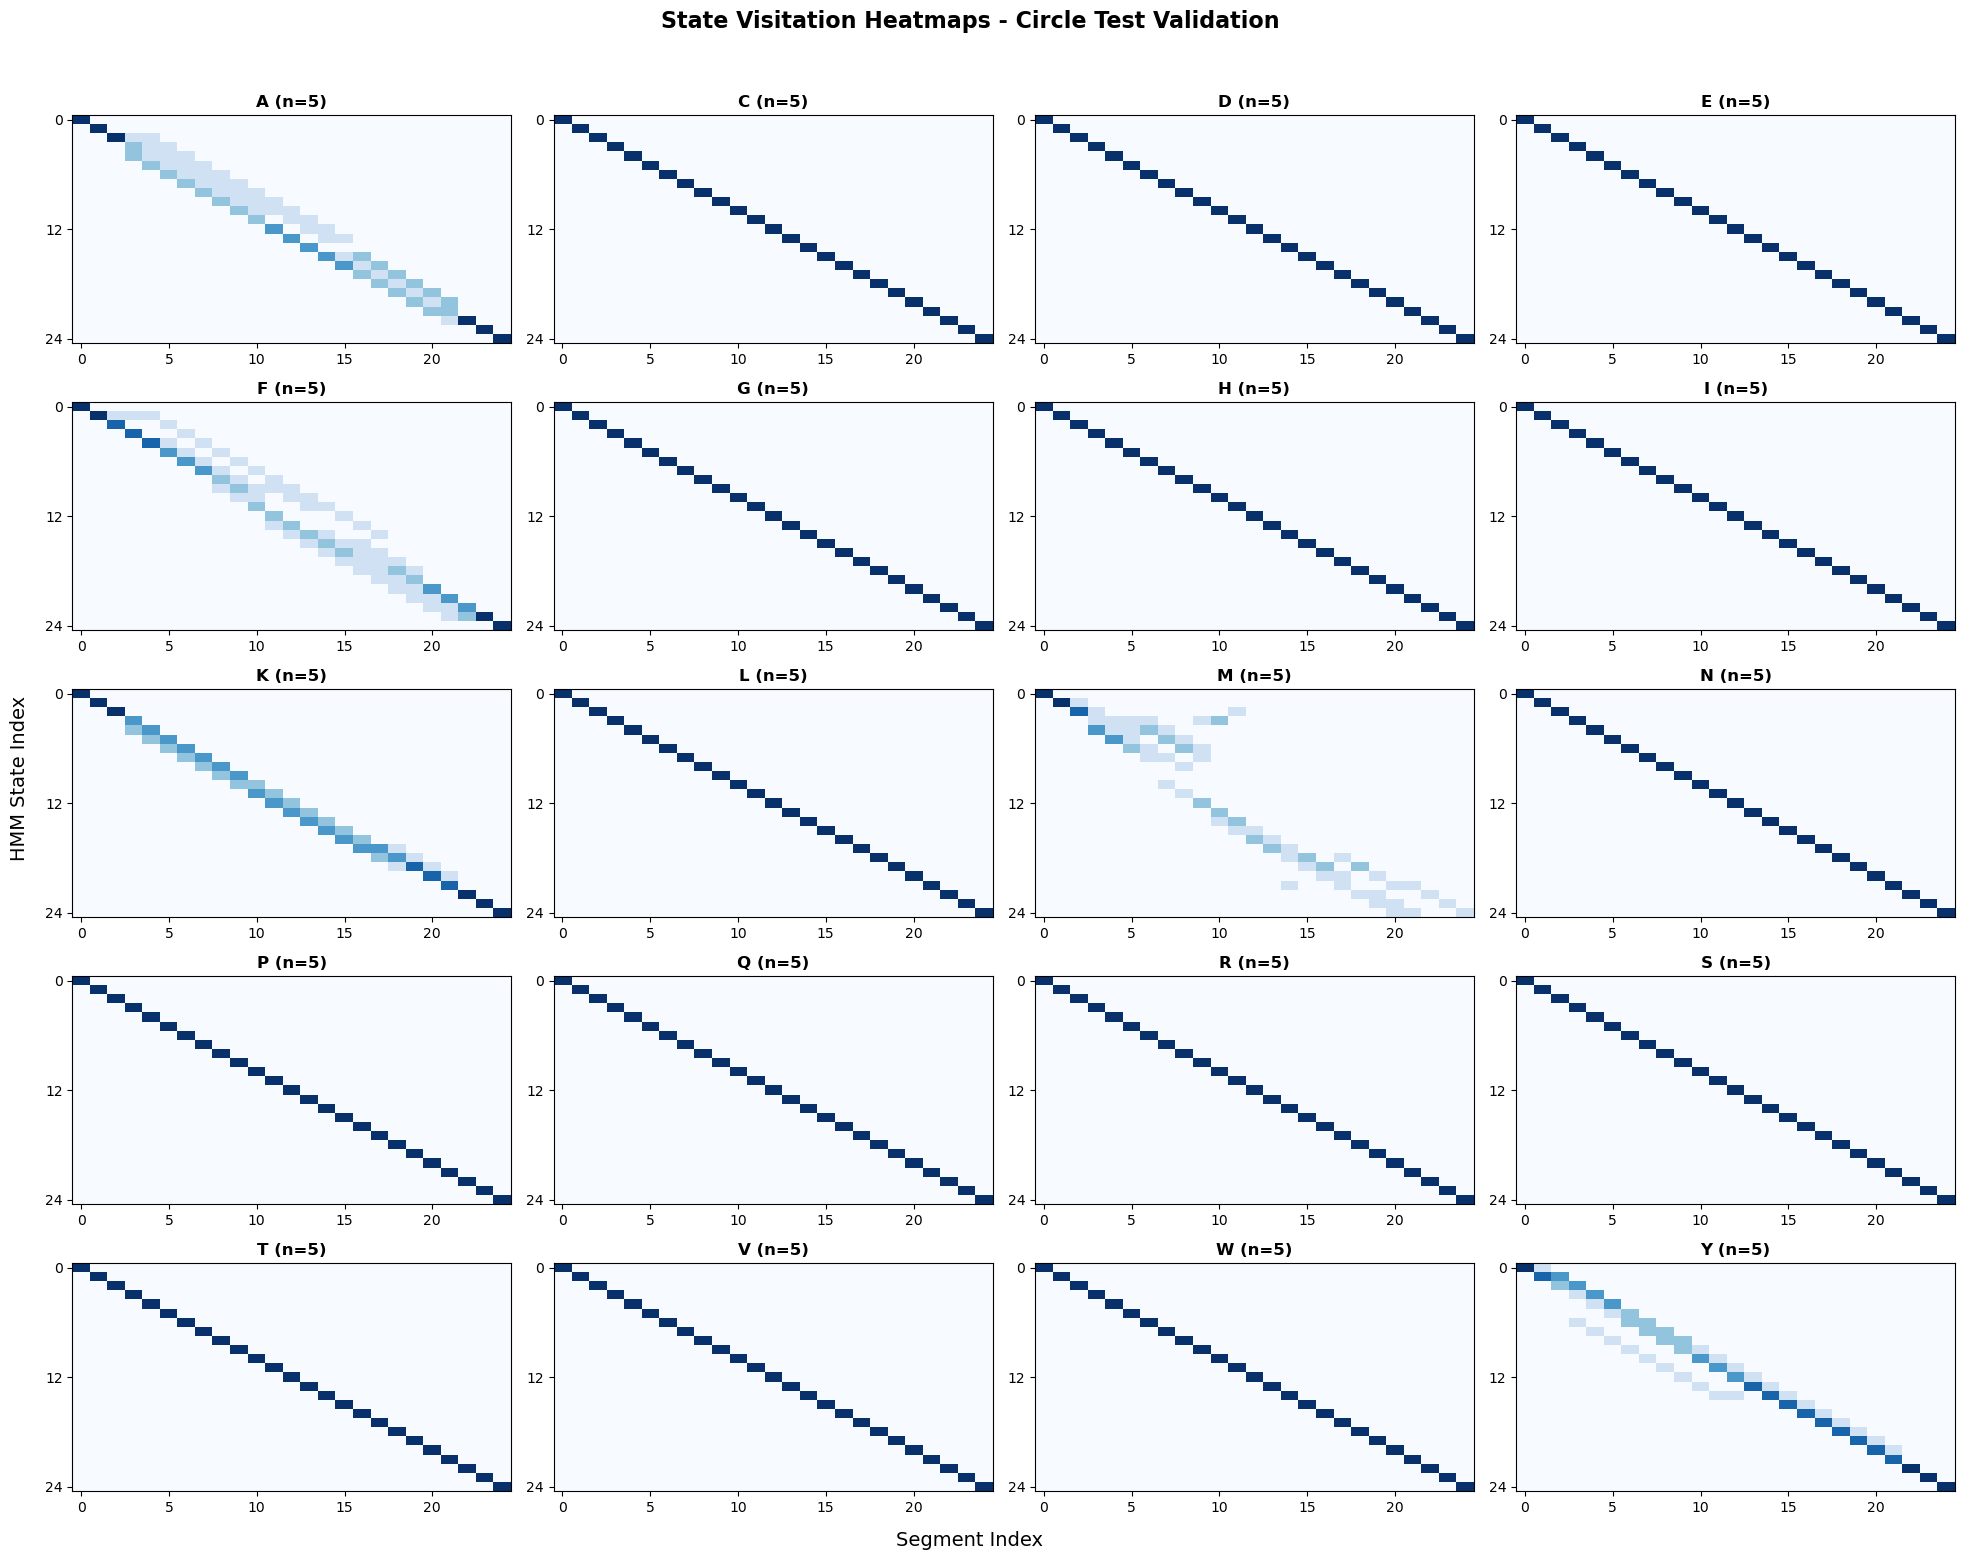

In [4]:
# Heatmap showing state visitation frequency
fig = plot_traceback_heatmap_grid(
    circle_test_dir,
    num_states=25,
    save_path="./traceback_grid_heatmap.pdf",
    suptitle="State Visitation Heatmaps - Circle Test Validation"
)
plt.show()
